#### Middleware

https://docs.langchain.com/oss/python/langchain/middleware/overview

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

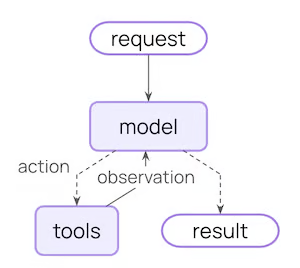

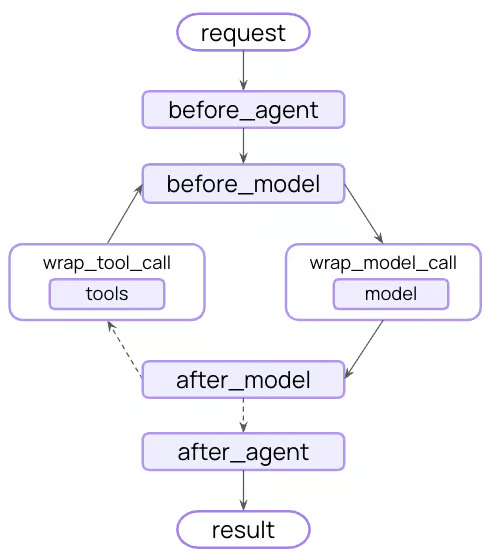

In [22]:

import os
from dotenv import load_dotenv

load_dotenv()

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
os.environ['GEMINI_API_KEY']=os.getenv('GEMINI_API_KEY')

In [23]:
import os
from langchain.chat_models import init_chat_model
# model = init_chat_model("groq:qwen/qwen3.6-27b")
model = init_chat_model("groq:openai/gpt-oss-120b")
response=model.invoke("Hellow, how are you?")
print(response)

content="Hello! I'm doing great, thank you for asking. How can I assist you today?" additional_kwargs={'reasoning_content': 'The user says "Hellow, how are you?" It\'s a casual greeting. The assistant should respond politely. No policy issues. So respond friendly.'} response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 78, 'total_tokens': 136, 'completion_time': 0.121622146, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.003821349, 'prompt_tokens_details': None, 'queue_time': 0.317745248, 'total_time': 0.125443495}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_49bfac06f1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a08025-3146-7773-96bd-1aa48e08c94d-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 78, 'output_tokens': 58, 'total_tokens': 136, 'output_token_details': {'reasoning': 31}}


### Summarization middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver 
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

In [7]:
agent = create_agent(
    model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model, 
            trigger=("messages", 10), 
            keep=("messages", 4)
            )
        ],
)

In [8]:
## run with thread id
config = {"configurable": {"thread_id": "Test-1"}}

In [9]:
#alternative test data
questions = [
    "What is the capital of France?",
    "What is the capital of Germany?",
    "What is the capital of Italy?",
    "What is the capital of Spain?",
    "What is the capital of Portugal?",
    "What is the capital of Switzerland?",
    "What is the capital of Austria?",
    "What is the capital of Belgium?",
    "What is the capital of Denmark?",
    "What is the capital of Finland?",
    "What is the capital of Iceland?",
    "What is the capital of Norway?",
    "What is the capital of Sweden?",
    "What is the capital of Switzerland?",]

for q in questions:
    response=agent.invoke({"messages" : [HumanMessage(content=q)]}, config)
    print(f"Messages :  {response}")
    print(f"Messages len : {len(response["messages"])}")

Messages :  {'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='8a6f50ed-ceac-4740-bcd5-dd3b458b654f'), AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'reasoning_content': 'The user asks a simple question: "What is the capital of France?" The answer is Paris. No policy issues. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 78, 'total_tokens': 124, 'completion_time': 0.103184393, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.003205906, 'prompt_tokens_details': None, 'queue_time': 0.337301338, 'total_time': 0.106390299}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4200b3f836', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07a45-a310-7c40-819d-7b3ca0b1fe2f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'out

In [10]:
## based on toekn size
from langchain_core.tools import tool

@tool
def search_hotels(city: str) -> str:
    """ search hotels in a given city - returns long response to use more tokens"""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym, jacuzzi
    2. Luxury Hotel - 4 star, $300/night, spa, pool, gym
    3. Comfort Hotel - 3 star, $200/night, spa, pool, gym
    """

agent = create_agent(
    model,
    checkpointer=InMemorySaver(),
    tools=[search_hotels],
    middleware=[
        SummarizationMiddleware(
            model=model, 
            trigger=("tokens", 550), 
            keep=("tokens", 200)
            )
        ],
)

In [12]:
config = {"configurable": {"thread_id": "Test-1"}}

# token counter
def count_tokens(messages):
    tool_chars = sum(len(str(m.content)) for m in messages)
    return tool_chars//4 ## 4 char is a token

In [14]:
#run test
cities = ["Paris", "Berlin", "Rome", "Madrid", "Lisbon"]

for city in cities:
    response=agent.invoke(
        {"messages" : [HumanMessage(content=f"find the hotels in {city}")]}, 
         config
         )
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~951 tokens, 6 messages
[HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nProvide hotel recommendations in Lisbon and Paris (including star rating, price, and key amenities) and be ready to refine the lists, supply detailed information for a selected hotel, or present additional options based on the user’s preferences.\n\n## SUMMARY\n- Initially prepared a list of Rome hotels (placeholder) then switched to Madrid, executing `search_hotels` and presenting three Madrid hotels:\n  1. Grand Hotel Madrid – 5★, $350/night, spa, outdoor pool, gym, jacuzzi, rooftop terrace, 24\u202fh concierge.  \n  2. Luxury Hotel Madrid – 4★, $300/night, spa, indoor pool, gym, business centre, complimentary breakfast.  \n  3. Comfort Hotel Madrid – 3★, $200/night, small spa, heated pool, fitness room, free Wi‑Fi, pet‑friendly rooms.  \n- User subsequently requested hotel searches for Lisbon and Paris but no tool calls have been made yet.\n\n## ARTIFACTS\n- **T

In [15]:
## based on toekn size
from langchain_core.tools import tool

@tool
def search_hotels(city: str) -> str:
    """ search hotels in a given city - returns long response to use more tokens"""
    return f"""Hotels in {city}:
    Grand Hotel - $350/night, City Inn $180/night, Holiday Inn $220/night
    """

agent = create_agent(
    model,
    checkpointer=InMemorySaver(),
    tools=[search_hotels],
    middleware=[
        SummarizationMiddleware(
            model=model, 
            trigger=("fraction", 0.05), 
            keep=("fraction", 0.02),
        )
    ],
)

config = {"configurable": {"thread_id": "Test-1"}}
#token counter
def count_tokens(messages):
    tool_chars = sum(len(str(m.content)) for m in messages)
    return tool_chars//4 ## 4 char is a token


In [17]:
#run test
cities = ["Paris", "Berlin", "Rome", "Madrid", "Lisbon"]

for city in cities:
    response=agent.invoke(
        {"messages" : [HumanMessage(content=f"find the hotels in {city}")]}, 
         config
         )
    tokens = count_tokens(response["messages"])
    fraction = tokens/131072
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~1670 tokens (1.2741%), 22 messages
[HumanMessage(content='find the hotels in Paris', additional_kwargs={}, response_metadata={}, id='b8d31963-6d2c-4272-ac52-159dbe31f167'), AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to find hotels in Paris. Use function search_hotels with city "Paris".', 'tool_calls': [{'id': 'fc_436ad73e-f148-4261-97fb-eaecda75f684', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 134, 'total_tokens': 181, 'completion_time': 0.09830476, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.005278804, 'prompt_tokens_details': None, 'queue_time': 0.382133916, 'total_time': 0.103583564}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07a56-0c33-7e

## Human in the loop

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
 - High-stakes operations requiring human approval (e.g. database writes, financial transactions).
 - Compliance workflows where human oversight is mandatory.
 - Long-running conversations where human feedback guides the agent.

In [24]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def your_read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def your_send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=model,
    tools=[your_read_email_tool, your_send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "your_send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "your_read_email_tool": False,
            }
        ),
    ],
)

In [27]:
from uuid import uuid4
from langgraph.types import Command

config = {
    "configurable": {
        "thread_id": f"email-test-{uuid4()}"
    }
}

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Send email to jhon@test.com with subject "
                    "'Hello' and body 'How are you'"
                ),
            }
        ]
    },
    config=config,
)

print(result.keys())
print(result.get("__interrupt__"))

dict_keys(['messages', '__interrupt__'])
[Interrupt(value={'action_requests': [{'name': 'your_send_email_tool', 'args': {'body': 'How are you', 'recipient': 'jhon@test.com', 'subject': 'Hello'}, 'description': "Tool execution requires approval\n\nTool: your_send_email_tool\nArgs: {'body': 'How are you', 'recipient': 'jhon@test.com', 'subject': 'Hello'}"}], 'review_configs': [{'action_name': 'your_send_email_tool', 'allowed_decisions': ['approve', 'edit', 'reject']}]}, id='2d7c289c12596584932e964b2651a1bf')]


In [29]:
from langgraph.types import Command

# Step 2: Approve
if "__interrupt__" in result:
    print("Paused! Approving ...")

    result = agent.invoke(
        Command(resume={
            "decisions" : [{"type" : "approve"}]
        }),
        config,
    )
    # print(result["messages"])
    print(f"Response : {result['messages'][0].content}")

Paused! Approving ...
Response : Send email to jhon@test.com with subject 'Hello' and body 'How are you'


In [30]:
## Reject



from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def your_read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def your_send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=model,
    tools=[your_read_email_tool, your_send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "your_send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "your_read_email_tool": False,
            }
        ),
    ],
)

In [ ]:
from uuid import uuid4
from langgraph.types import Command

config = {
    "configurable": {
        "thread_id": f"email-test-{uuid4()}"
    }
}

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Send email to jhon@test.com with subject "
                    "'Hello' and body 'How are you'"
                ),
            }
        ]
    },
    config=config,
)

# print(result.keys())
# print(result.get("__interrupt__"))

dict_keys(['messages', '__interrupt__'])
[Interrupt(value={'action_requests': [{'name': 'your_send_email_tool', 'args': {'body': 'How are you', 'recipient': 'jhon@test.com', 'subject': 'Hello'}, 'description': "Tool execution requires approval\n\nTool: your_send_email_tool\nArgs: {'body': 'How are you', 'recipient': 'jhon@test.com', 'subject': 'Hello'}"}], 'review_configs': [{'action_name': 'your_send_email_tool', 'allowed_decisions': ['approve', 'edit', 'reject']}]}, id='3e700e9fad437c29f4a2c15ca6bd0354')]


In [32]:
from langgraph.types import Command

# Step 2: Approve
if "__interrupt__" in result:
    print("Paused! Approving ...")

    result = agent.invoke(
        Command(resume={
            "decisions" : [{"type" : "reject"}]
        }),
        config,
    )
    # print(result["messages"])
    print(f"Response : {result['messages'][0].content}")

Paused! Approving ...
Response : Send email to jhon@test.com with subject 'Hello' and body 'How are you'
